In [1]:
import sys
import importlib

if "Utils.CADTensorGenerator" in sys.modules:
    del sys.modules["Utils.CADTensorGenerator"]

import Utils.CADTensorGenerator as ctg
importlib.reload(ctg)

from Utils.CADTensorGenerator import CADTensorGenerator

print("fps_3d exists:", hasattr(CADTensorGenerator, "fps_3d"))
print("vertex_area_lumped exists:", hasattr(CADTensorGenerator, "vertex_area_lumped"))
print("module file:", ctg.__file__)

fps_3d exists: True
vertex_area_lumped exists: True
module file: /Users/user/Desktop/VoronoiImp-main/Utils/CADTensorGenerator.py


In [2]:
import os
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  # standard alias
from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from HDVClassNet.PP_net import PPNet
from HDVClassNet.VoronoiDecorder import VoronoiDecoder
from Training.TrainLoss import TrainLoss
import pyvista as pv
try:
    pv.set_jupyter_backend("trame")
except Exception:
    pass

# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)
# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Code Directory: /Users/user/Desktop/VoronoiImp-main
Test Step files Directory: /Users/user/Desktop/VoronoiImp-main/Testparts
device: cpu


In [3]:
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"

shape_path = str(CircularSurf1)
generator = CADTensorGenerator(
    deflection=0.5,
    angle=0.5,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=80,
    n_v=80,
    device=device,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=shape_path,
    input_ring=1,
    visualize=False,
)

uv = tensors["uv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
faces_ijk = tensors["faces_ijk"]
pv_faces = tensors["pv_faces"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
min_vol_frac = tensors["min_vol_frac"]
viz = CADVisualizer()
loss_obj = TrainLoss()


MinVolFrac: 0.07359372824430466
uv device: cpu


In [4]:
import copy
from dataclasses import dataclass

import torch


@dataclass
class TrainingConfig:
    seed_number: int = 15
    use_anisotropy: bool = True
    target_volfrac: float = 0.5

    lam_fem: float = 1.0
    lam_vol: float = 2.0
    lam_rep: float = 0.5
    lam_bnd: float = 0.5
    lam_best_vol: float = 5.0

    num_steps: int = 10000
    context_vector_size: int = 8

    tau: float = 0.02
    beta: float = 0.05

    lr_seed_refine: float = 2e-4
    lr_delta_head: float = 2e-4
    lr_mlp: float = 2e-4
    lr_w_head: float = 2e-4
    lr_h_head: float = 2e-4

    log_every: int = 50
    sweep_every: int | None = 300
    early_stop_start: int = 300
    patience: int = 300
    min_delta: float = 1e-4

    eps: float = 1e-12


class RunningNorm:
    def __init__(self, momentum=0.99, eps=1e-12):
        self.val = None
        self.momentum = momentum
        self.eps = eps

    def update(self, x: float) -> float:
        x = abs(float(x)) + self.eps
        if self.val is None:
            self.val = x
        else:
            self.val = self.momentum * self.val + (1.0 - self.momentum) * x
        return max(self.val, 1e-8)


class CADTrainer:
    """
    Trainer for Voronoi / density optimization.

    Expected external objects:
      - generator
      - loss_obj
      - viz
      - decoder_cls
      - ppnet_cls
    """

    def __init__(self, generator, loss_obj, viz, decoder_cls, ppnet_cls, config: TrainingConfig):
        self.generator = generator
        self.loss_obj = loss_obj
        self.viz = viz
        self.decoder_cls = decoder_cls
        self.ppnet_cls = ppnet_cls
        self.cfg = config

    def _build_models(
        self,
        device,
        seed_number,
        boundary_idx_ring1,
        face_id,
        use_anisotropy,
        context_vector_size,
    ):
        face_u_periodic = torch.tensor([False], device=device)
        face_v_periodic = torch.tensor([False], device=device)
        seed_face_id = torch.zeros(seed_number, dtype=torch.long, device=device)

        decoder = self.decoder_cls(
            n_seeds=seed_number,
            boundary_solid_idx=boundary_idx_ring1,
            seed_face_id=seed_face_id,
            face_u_periodic=face_u_periodic,
            face_v_periodic=face_v_periodic,
            use_anisotropy=False,
        ).to(device)

        ppnet = self.ppnet_cls(
            context_dim=context_vector_size,
            n_seeds=seed_number,
            use_anisotropy=use_anisotropy,
        ).to(device)

        return decoder, ppnet

    def _build_optimizer(self, ppnet):
        cfg = self.cfg
        return torch.optim.Adam([
            {"params": ppnet.seed_refine.parameters(), "lr": cfg.lr_seed_refine},
            {"params": ppnet.delta_head.parameters(),  "lr": cfg.lr_delta_head},
            {"params": ppnet.mlp.parameters(),         "lr": cfg.lr_mlp},
            {"params": ppnet.w_head.parameters(),      "lr": cfg.lr_w_head},
            {"params": ppnet.h_head.parameters(),      "lr": cfg.lr_h_head},
        ])

    def train(
        self,
        uv,
        points_xyz,
        face_areas,
        faces_ijk,
        face_id,
        boundary_idx_ring1,
    ):
        cfg = self.cfg
        device = uv.device
        dtype = uv.dtype
        mid_step = cfg.num_steps // 2
        vertices_number = uv.shape[0]

        # ---------------- boundary / init seeds ----------------
        boundary = torch.unique(boundary_idx_ring1)
        seed_idx = self.generator.fps_3d(
        points_xyz,
        cfg.seed_number,
        exclude_idx=boundary,
        )
        uv_init = uv[seed_idx].clone()

        # ---------------- constants ----------------
        A_v = self.generator.vertex_area_lumped(vertices_number, faces_ijk, face_areas)

        decoder, ppnet = self._build_models(
            device=device,
            seed_number=cfg.seed_number,
            boundary_idx_ring1=boundary_idx_ring1,
            face_id=face_id,
            use_anisotropy=cfg.use_anisotropy,
            context_vector_size=cfg.context_vector_size,
        )

        opt = self._build_optimizer(ppnet)
        context = torch.zeros(1, cfg.context_vector_size, device=device, dtype=dtype)

        # ---------------- running normalization ----------------
        norm_vol = RunningNorm()
        norm_rep = RunningNorm()
        norm_bnd = RunningNorm()

        # ---------------- tracking ----------------
        best_score = float("inf")
        best_step = -1
        best_rho = None
        best_seeds = None
        best_pred = None
        steps_since_improve = 0

        initial_shape_density = None
        mid_shape_density = None
        final_shape_density = None

        seed_points_init = None
        seed_points_mid = None
        seed_points_final = None

        rho0 = None
        seeds0 = None

        history = []

        for step in range(cfg.num_steps):
            decoder.beta = cfg.beta

            opt.zero_grad(set_to_none=True)

            # ---- PPNet forward ----
            pred = ppnet(context, uv_init, offset_scale=0.15, clamp01=True)
            seeds_raw = pred["seeds_raw"][0]
            w_raw = pred["w_raw"][0]
            h_raw = pred["h_raw"][0]
            gates = pred.get("gate_probs", None)
            gates = gates[0] if gates is not None else None

            # ---- decoder forward ----
            w_soft, d, M, seeds, rho, t_raw, t_uv, h, Q_used = decoder(
                uv,
                tau=cfg.tau,
                seeds_raw=seeds_raw,
                w_raw=w_raw,
                h_raw=h_raw,
                points_face_id=face_id,
            )

            # ---- losses ----
            loss_vol = self.loss_obj.volume_loss_constant_height(
                rho=rho,
                A_v=A_v,
                target_volfrac=cfg.target_volfrac,
                eps=cfg.eps,
            )

            loss_rep = self.loss_obj.seed_repulsion_term(
                seeds=seeds,
                gates=gates,
                sigma=0.08,
                eps=cfg.eps,
            )

            loss_bnd = self.loss_obj.boundary_repulsion_term(
                seeds=seeds,
                gates=gates,
                margin=0.05,
                eps=cfg.eps,
            )

            # Optional normalized combination
            n_vol = norm_vol.update(loss_vol.detach().item())
            n_rep = norm_rep.update(loss_rep.detach().item())
            n_bnd = norm_bnd.update(loss_bnd.detach().item())

            L_total = (
                cfg.lam_vol * (loss_vol / n_vol) +
                cfg.lam_rep * (loss_rep / n_rep) +
                cfg.lam_bnd * (loss_bnd / n_bnd)
            )

            L_total.backward()
            opt.step()

            # ---- stats ----
            with torch.no_grad():
                vol_frac = (rho * A_v).sum() / (A_v.sum() + cfg.eps)
                vol_dev = torch.abs(vol_frac - cfg.target_volfrac)

                # selection score for "best solution"
                score = float(
                    L_total.detach().item() +
                    cfg.lam_best_vol * vol_dev.detach().item()
                )

                if score < (best_score - cfg.min_delta):
                    best_score = score
                    best_step = step
                    best_rho = rho.detach().clone()
                    best_seeds = seeds.detach().clone()
                    best_pred = {
                        "seeds_raw": seeds_raw.detach().clone(),
                        "w_raw": w_raw.detach().clone(),
                        "h_raw": h_raw.detach().clone(),
                        "gates": None if gates is None else gates.detach().clone(),
                    }
                    steps_since_improve = 0
                else:
                    steps_since_improve += 1

                # ---- snapshots ----
                if step == 0:
                    initial_shape_density = rho.detach().clone()
                    seed_points_init = self.generator.seeds_uv_to_xyz_nearest(seeds, uv, points_xyz)

                if step == mid_step:
                    mid_shape_density = rho.detach().clone()
                    seed_points_mid = self.generator.seeds_uv_to_xyz_nearest(seeds, uv, points_xyz)

                # ---- logging baselines ----
                if rho0 is None:
                    rho0 = rho.detach().clone()
                if seeds0 is None:
                    seeds0 = seeds.detach().clone()

                drho = float((rho - rho0).abs().mean().item())
                dseed = float((seeds - seeds0).abs().mean().item())

                rho_min = float(rho.min().item())
                rho_mean = float(rho.mean().item())
                rho_max = float(rho.max().item())

                g_mean = 0.0
                g_count = 0
                for p in ppnet.parameters():
                    if p.grad is not None:
                        g_mean += float(p.grad.detach().abs().mean().item())
                        g_count += 1
                g_mean = g_mean / max(g_count, 1)

                row = {
                    "step": step,
                    "L_total": float(L_total.detach().item()),
                    "loss_vol": float(loss_vol.detach().item()),
                    "loss_rep": float(loss_rep.detach().item()),
                    "loss_bnd": float(loss_bnd.detach().item()),
                    "vol_frac": float(vol_frac.detach().item()),
                    "vol_dev": float(vol_dev.detach().item()),
                    "rho_min": rho_min,
                    "rho_mean": rho_mean,
                    "rho_max": rho_max,
                    "drho": drho,
                    "dseed": dseed,
                    "grad_mean": g_mean,
                    "best_score": best_score,
                    "best_step": best_step,
                }
                history.append(row)

                if step % cfg.log_every == 0 or step == cfg.num_steps - 1:
                    print(
                        f"[{step:05d}] "
                        f"L={row['L_total']:.4e} "
                        f"vol={row['vol_frac']:.3f} dev={row['vol_dev']:.3f} target={cfg.target_volfrac:.3f} "
                        f"rho(min/mean/max)={rho_min:.3f}/{rho_mean:.3f}/{rho_max:.3f} "
                        f"rep={row['loss_rep']:.3e} bnd={row['loss_bnd']:.3e} "
                        f"Δrho={drho:.2e} Δseed={dseed:.2e} "
                        f"grad_mean={g_mean:.2e} "
                        f"best={best_score:.4e}@{best_step}"
                    )

                # ---- early stopping ----
                if (
                    step >= cfg.early_stop_start and
                    steps_since_improve >= cfg.patience
                ):
                    print(f"Early stopping at step {step} | best_step={best_step} | best_score={best_score:.6f}")
                    break

        # ---------------- final / best ----------------
        if best_rho is None:
            with torch.no_grad():
                best_rho = rho.detach().clone()
                best_seeds = seeds.detach().clone()
                best_step = step
                best_score = float(L_total.detach().item())

        with torch.no_grad():
            final_shape_density = best_rho.clone()
            seed_points_final = self.generator.seeds_uv_to_xyz_nearest(best_seeds, uv, points_xyz)

            if mid_shape_density is None:
                mid_shape_density = final_shape_density.clone()
                seed_points_mid = seed_points_final

        print(f"FINAL RETURNED: best_step={best_step}, best_score={best_score:.6f}")

        return {
            "decoder": decoder,
            "ppnet": ppnet,
            "optimizer": opt,
            "history": history,
            "best_score": best_score,
            "best_step": best_step,
            "best_rho": best_rho,
            "best_seeds": best_seeds,
            "best_pred": best_pred,
            "Initial_shape_density": initial_shape_density,
            "Mid_shape_density": mid_shape_density,
            "Final_shape_density": final_shape_density,
            "seed_points_init": seed_points_init,
            "seed_points_mid": seed_points_mid,
            "seed_points_final": seed_points_final,
            "A_v": A_v,
            "uv_init": uv_init,
        }

    def visualize_result(self, result, points_xyz, faces_ijk):
        density_init_viz = self.viz.viz_normalize(result["Initial_shape_density"])
        density_mid_viz = self.viz.viz_normalize(result["Mid_shape_density"])
        density_fin_viz = self.viz.viz_normalize(result["Final_shape_density"])

        pv_faces_fixed = self.generator.faces_ijk_to_pv_faces(faces_ijk)

        self.viz.plot_density_and_seedpoints_3stage(
            mesh_points=points_xyz.detach().cpu().numpy(),
            pv_faces=pv_faces_fixed,
            density_init=density_init_viz.detach().cpu().numpy(),
            density_mid=density_mid_viz.detach().cpu().numpy(),
            density_final=density_fin_viz.detach().cpu().numpy(),
            seed_points_init=result["seed_points_init"],
            seed_points_mid=result["seed_points_mid"],
            seed_points_final=result["seed_points_final"],
            shared_clim=False,
        )

[00000] L=3.0000e+00 vol=0.204 dev=0.004 target=0.200 rho(min/mean/max)=0.001/0.223/1.000 rep=2.102e-05 bnd=1.112e-01 Δrho=0.00e+00 Δseed=0.00e+00 grad_mean=8.32e+00 best=3.0176e+00@0
[00050] L=9.8045e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.974e-05 bnd=1.121e-01 Δrho=1.60e-02 Δseed=1.60e-03 grad_mean=1.88e-01 best=9.8071e-01@50
[00100] L=9.5912e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.830e-05 bnd=1.122e-01 Δrho=1.54e-02 Δseed=1.70e-03 grad_mean=9.63e-03 best=9.5912e-01@100
[00150] L=9.4120e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.638e-05 bnd=1.128e-01 Δrho=2.02e-02 Δseed=2.30e-03 grad_mean=8.57e-01 best=9.3788e-01@148
[00200] L=9.1708e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.441e-05 bnd=1.136e-01 Δrho=3.00e-02 Δseed=3.45e-03 grad_mean=1.16e-01 best=9.1715e-01@200
[00250] L=9.0602e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0

/Users/user/Desktop/VoronoiImp-main/Utils/CADVisualizer.py:254: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  pl.show()


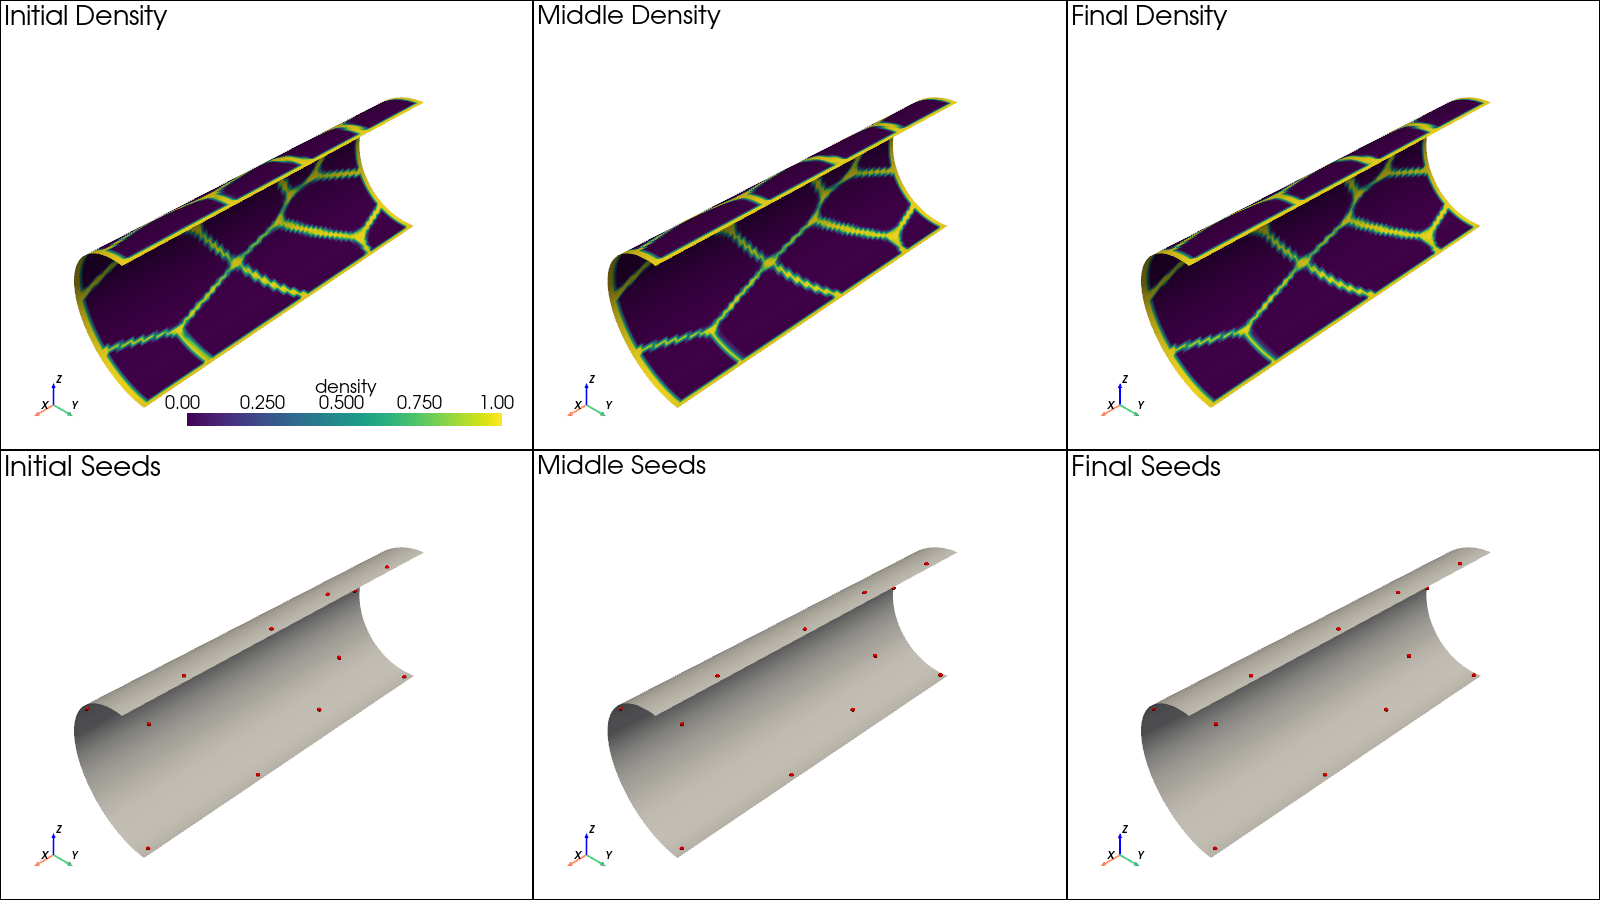

In [5]:
cfg = TrainingConfig(
    seed_number=15,
    use_anisotropy=False,
    target_volfrac=0.2,
    lam_vol=2.0,
    lam_rep=0.5,
    lam_bnd=0.5,
    lam_best_vol=5.0,
    num_steps=10000,
    context_vector_size=8,
    tau=0.02,
    beta=0.05,
    log_every=50,
    early_stop_start=300,
    patience=300,
    min_delta=1e-4,
)

trainer = CADTrainer(
    generator=generator,
    loss_obj=loss_obj,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    config=cfg,
)

result = trainer.train(
    uv=uv,
    points_xyz=points_xyz,
    face_areas=face_areas,
    faces_ijk=faces_ijk,
    face_id=face_id,
    boundary_idx_ring1=boundary_idx_ring1,
)

trainer.visualize_result(result, points_xyz, faces_ijk)

In [6]:
# solid, thr_used = viz.visualize_density_thresholded(
#     points=points_xyz,
#     pv_faces=generator.pv_faces_fixed,
#     density_total=density_fin_viz,
#     thr=0.8,          
#     show_solid=True
# )

In [12]:
import torch
from neuraltomo_fem import run_fem_loss
from problems.TipCantilever_30_20_20_midLoad import TipCantilever_30_20_20_midLoad

# build problem from repo
problem = TipCantilever_30_20_20_midLoad()

device = "cuda" if torch.cuda.is_available() else "cpu"
fem = run_fem_loss.NeuralTOMOFEM(problem, device=device, isotropic=False)

nelx = problem.mesh["nelx"]
nely = problem.mesh["nely"]
nelz = problem.mesh["nelz"]
nele = nelx * nely * nelz

density = torch.full((nele,), 0.2, device=fem.device)
fiber_dir = torch.randn(nele, 3, device=fem.device)

stress, comp = fem(density, fiber_dir, penal=3)

print("stress:", float(stress))
print("comp  :", float(comp))

stress: 2.2488500235340325e-06
comp  : 51161604292608.0
